In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df=pd.read_csv("players_20.csv")

In [3]:
df

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,245006,https://sofifa.com/player/245006/shuai-shao/20...,Shao Shuai,邵帅,22,1997-03-10,186,79,China PR,Beijing Renhe FC,...,43+2,42+2,42+2,42+2,43+2,45+2,46+2,46+2,46+2,45+2
18274,250995,https://sofifa.com/player/250995/mingjie-xiao/...,Xiao Mingjie,Mingjie Xiao,22,1997-01-01,177,66,China PR,Shanghai SIPG FC,...,44+2,43+2,43+2,43+2,44+2,46+2,47+2,47+2,47+2,46+2
18275,252332,https://sofifa.com/player/252332/wei-zhang/20/...,Zhang Wei,张威,19,2000-05-16,186,75,China PR,Hebei China Fortune FC,...,47+2,49+2,49+2,49+2,47+2,47+2,49+2,49+2,49+2,47+2
18276,251110,https://sofifa.com/player/251110/haijian-wang/...,Wang Haijian,汪海健,18,2000-08-02,185,74,China PR,Shanghai Greenland Shenhua FC,...,48+2,48+2,48+2,48+2,48+2,48+2,49+2,49+2,49+2,48+2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


In [5]:
df.shape

(18278, 104)

In [6]:
df.isnull().sum()

sofifa_id        0
player_url       0
short_name       0
long_name        0
age              0
              ... 
lb            2036
lcb           2036
cb            2036
rcb           2036
rb            2036
Length: 104, dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
#player stat features
columns = ['overall','attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing',
           'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
           'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 
           'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
           'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 
           'mentality_composure', 'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle', 'goalkeeping_diving',
           'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes']
data = df[columns]
data

,overall,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,94,88,95,70,92,88,97,93,94,92,...,75,96,33,37,26,6,11,15,14,8
1,93,84,94,89,83,87,89,81,76,77,...,85,95,28,32,24,7,11,15,14,11
2,92,87,87,62,87,87,96,88,87,81,...,90,94,27,26,29,9,9,15,15,11
3,91,13,11,15,43,13,12,13,14,40,...,11,68,27,12,18,87,92,78,90,89
4,91,81,84,61,89,83,95,83,79,83,...,88,91,34,27,22,11,12,6,8,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,48,21,17,40,35,27,24,23,21,28,...,39,41,45,50,52,5,5,13,5,14
18274,48,24,20,42,43,28,32,24,29,39,...,37,35,42,53,57,13,6,14,11,9
18275,48,32,33,49,53,32,40,32,32,55,...,36,39,46,52,46,7,8,10,6,14
18276,48,39,34,47,54,28,42,37,39,48,...,36,40,39,44,54,14,9,13,13,13


In [9]:
data.shape

(18278, 35)

In [10]:
data.isnull().sum()

overall                       0
attacking_crossing            0
attacking_finishing           0
attacking_heading_accuracy    0
attacking_short_passing       0
attacking_volleys             0
skill_dribbling               0
skill_curve                   0
skill_fk_accuracy             0
skill_long_passing            0
skill_ball_control            0
movement_acceleration         0
movement_sprint_speed         0
movement_agility              0
movement_reactions            0
movement_balance              0
power_shot_power              0
power_jumping                 0
power_stamina                 0
power_strength                0
power_long_shots              0
mentality_aggression          0
mentality_interceptions       0
mentality_positioning         0
mentality_vision              0
mentality_penalties           0
mentality_composure           0
defending_marking             0
defending_standing_tackle     0
defending_sliding_tackle      0
goalkeeping_diving            0
goalkeep

In [11]:
data.describe()

,overall,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,66.244994,49.718405,45.590218,52.221468,58.748003,42.809388,55.596509,47.325692,42.708885,52.768848,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,6.949953,18.325403,19.594609,17.428429,14.679653,17.701815,18.929118,18.422991,17.433612,15.246454,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,48.000000,5.000000,2.000000,5.000000,7.000000,3.000000,4.000000,6.000000,4.000000,8.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,62.000000,38.000000,30.000000,44.000000,54.000000,30.000000,50.000000,34.000000,31.000000,43.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,66.000000,54.000000,49.000000,56.000000,62.000000,44.000000,61.000000,49.000000,41.000000,56.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,71.000000,64.000000,62.000000,64.000000,68.000000,56.000000,68.000000,62.000000,56.000000,64.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,94.000000,93.000000,95.000000,93.000000,92.000000,90.000000,97.000000,94.000000,94.000000,92.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


## Task 3

## (i) Prepare a rank ordered list of top 10 countries with most players. Which countries are producing the most footballers that play at this level?

In [14]:
df.nationality

0        Argentina
1         Portugal
2           Brazil
3         Slovenia
4          Belgium
           ...    
18273     China PR
18274     China PR
18275     China PR
18276     China PR
18277     China PR
Name: nationality, Length: 18278, dtype: object

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
# Group by 'Nationality' and count the number of players per country
top_countries = df['nationality'].value_counts().head(10)


In [16]:
# Display the rank-ordered list of top 10 countries
print(top_countries)


nationality
England        1667
Germany        1216
Spain          1035
France          984
Argentina       886
Brazil          824
Italy           732
Colombia        591
Japan           453
Netherlands     416
Name: count, dtype: int64


Text(0, 0.5, 'No of players')

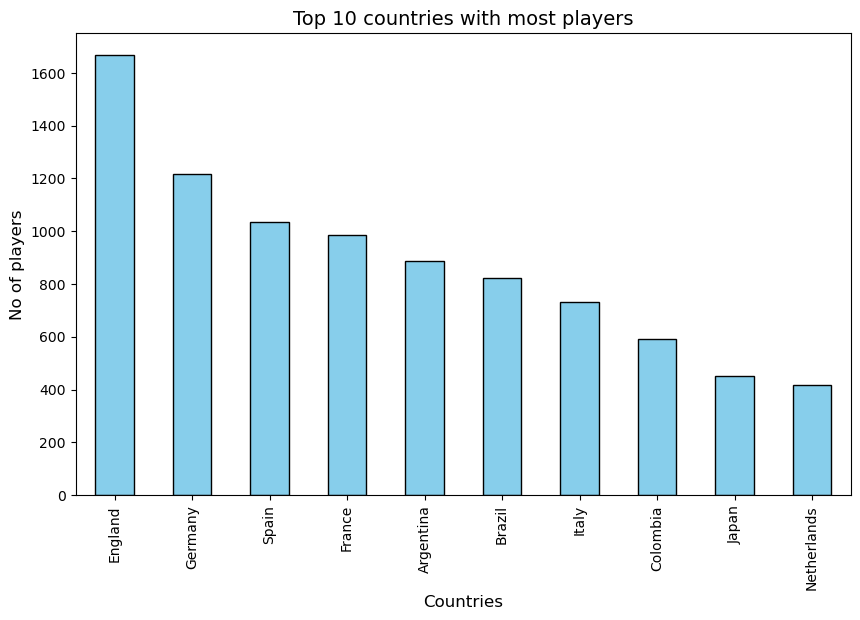

In [17]:
#barplot
plt.figure(figsize=(10,6))
top_countries.plot(kind='bar',color='skyblue',edgecolor='black')
plt.title('Top 10 countries with most players',fontsize=14)
plt.xlabel('Countries',fontsize=12)
plt.ylabel('No of players',fontsize=12)

## (ii)Plot the distribution of overall rating vs. age of players. Interpret what is the age after which a player stops improving?

In [20]:
df.overall

0        94
1        93
2        92
3        91
4        91
         ..
18273    48
18274    48
18275    48
18276    48
18277    48
Name: overall, Length: 18278, dtype: int64

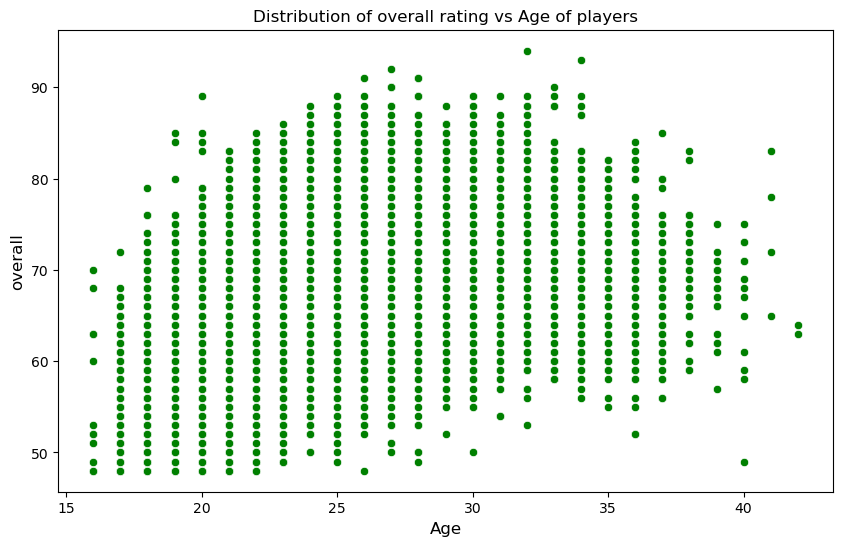

In [21]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x='age',y='overall',color='green')
plt.xlabel('Age',fontsize=12)
plt.ylabel('overall',fontsize=12)
plt.title('Distribution of overall rating vs Age of players')
plt.show()

Young Players (Ages 16-20):
You may notice that younger players (16-20 years old) typically have lower Overall ratings compared to older players.
This is because they are still developing their skills and reaching their full potential.

* Players in their Early 20s (Ages 21-25):
Around this age group, players usually start improving rapidly, and you might see a sharp rise in their Overall rating.
This could be the period where players are in their prime and improving the most.

* Peak Performance (Ages 25-27):
Most players tend to reach their peak performance in terms of Overall rating around their mid-20s 

* Players in their Late 20s to Early 30s (Ages 28-32): 
After the peak, players Overall ratings usually stabilize or gradually decline as they age.
You might see that older players have relatively consistent Overall ratings but do not improve much. 
Some players may still be top performers (due to experience), but the rate of improvement slows.

* Aging Players (Ages 33-36):
For players in their 30s, you might notice a decline in Overall ratings. 
* we can find the players overall rating stops to improve at the age between 36-40

## (iii)Which type of offensive players tends to get paid the most: the striker, the right-winger, or the left-winger?

player_positions
LW     9681.818182
RW     6208.791209
ST    10256.495301
Name: wage_eur, dtype: float64


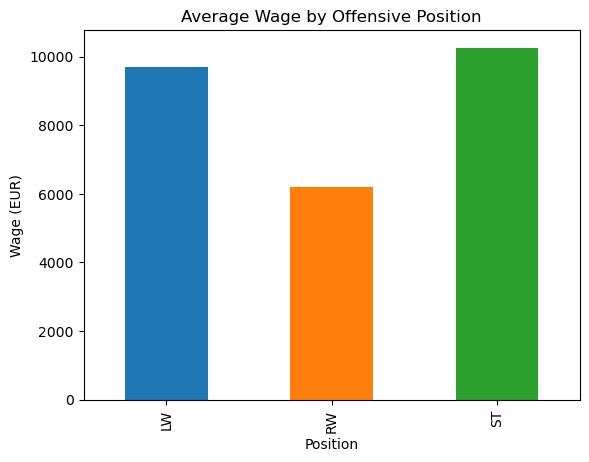

In [25]:
offensive_positions = ['ST', 'RW', 'LW']
df_offensive = df[df['player_positions'].isin(offensive_positions)]
average_wages = df_offensive.groupby('player_positions')['wage_eur'].mean()
print(average_wages)
average_wages.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Average Wage by Offensive Position')
plt.xlabel('Position')
plt.ylabel('Wage (EUR)')
plt.show()

### "The Striker" tends to get paid the most.

In [26]:
#player stat features
columns = ['overall','attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy', 'attacking_short_passing',
           'attacking_volleys', 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing',
           'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 
           'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots',
           'mentality_aggression', 'mentality_interceptions', 'mentality_positioning', 'mentality_vision', 'mentality_penalties', 
           'mentality_composure', 'defending_marking', 'defending_standing_tackle', 'defending_sliding_tackle', 'goalkeeping_diving',
           'goalkeeping_handling', 'goalkeeping_kicking', 'goalkeeping_positioning', 'goalkeeping_reflexes']
data = df[columns]
data

,overall,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,94,88,95,70,92,88,97,93,94,92,...,75,96,33,37,26,6,11,15,14,8
1,93,84,94,89,83,87,89,81,76,77,...,85,95,28,32,24,7,11,15,14,11
2,92,87,87,62,87,87,96,88,87,81,...,90,94,27,26,29,9,9,15,15,11
3,91,13,11,15,43,13,12,13,14,40,...,11,68,27,12,18,87,92,78,90,89
4,91,81,84,61,89,83,95,83,79,83,...,88,91,34,27,22,11,12,6,8,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18273,48,21,17,40,35,27,24,23,21,28,...,39,41,45,50,52,5,5,13,5,14
18274,48,24,20,42,43,28,32,24,29,39,...,37,35,42,53,57,13,6,14,11,9
18275,48,32,33,49,53,32,40,32,32,55,...,36,39,46,52,46,7,8,10,6,14
18276,48,39,34,47,54,28,42,37,39,48,...,36,40,39,44,54,14,9,13,13,13


In [27]:
data.isnull().sum()

overall                       0
attacking_crossing            0
attacking_finishing           0
attacking_heading_accuracy    0
attacking_short_passing       0
attacking_volleys             0
skill_dribbling               0
skill_curve                   0
skill_fk_accuracy             0
skill_long_passing            0
skill_ball_control            0
movement_acceleration         0
movement_sprint_speed         0
movement_agility              0
movement_reactions            0
movement_balance              0
power_shot_power              0
power_jumping                 0
power_stamina                 0
power_strength                0
power_long_shots              0
mentality_aggression          0
mentality_interceptions       0
mentality_positioning         0
mentality_vision              0
mentality_penalties           0
mentality_composure           0
defending_marking             0
defending_standing_tackle     0
defending_sliding_tackle      0
goalkeeping_diving            0
goalkeep

In [28]:
data.shape

(18278, 35)

In [58]:
# Select relevant attributes for clustering
clustering_features = [
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic', 
    'stamina', 'ball_control', 'agility', 'strength'
]

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[clustering_features])

# Use PCA for dimensionality reduction
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(reduced_features)

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], hue=df['Cluster'], palette='viridis', alpha=0.7)
plt.title('Player Clusters')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


KeyError: "['stamina', 'ball_control', 'agility', 'strength'] not in index"